# 01 Mixer Calibrations

Run this notebook after 00_hardware_defintion.ipynb. It reuses the shared session opened there when both notebooks share a kernel, or reopens the same sample and cooldown session from the bootstrap metadata written by notebook 00.
It also summarizes current mixer targets and provides both auto and manual mixer calibration paths.

By default, both calibration paths are in preview mode so the notebook can be executed safely end-to-end before enabling live calibration.

## 0. Imports and Session Bootstrap

Attach to the shared session from notebook 00 when it is already live in the current kernel.
If this notebook is running in a fresh kernel, reopen the same sample and cooldown session from the saved bootstrap metadata.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, r"E:\qubox")

from qubox.notebook import MixerCalibrationConfig
from qubox.notebook import SAMeasurementHelper
from qubox.notebook import get_notebook_session_bootstrap_path
from qubox.notebook import get_shared_session
from qubox.notebook import require_shared_session
from qubox.notebook import resolve_active_mixer_targets

REGISTRY_BASE = Path(r"E:\qubox")
SAMPLE_ID = "post_cavity_sample_A"
COOLDOWN_ID = "cd_2025_02_22"
SESSION_BOOTSTRAP_PATH = get_notebook_session_bootstrap_path(
    sample_id=SAMPLE_ID,
    cooldown_id=COOLDOWN_ID,
    registry_base=REGISTRY_BASE,)

existing_session = get_shared_session()
session = require_shared_session(
    bootstrap_path=SESSION_BOOTSTRAP_PATH,
    sample_id=SAMPLE_ID,
    cooldown_id=COOLDOWN_ID,
    registry_base=REGISTRY_BASE,
    qop_ip="10.157.36.68",
    cluster_name="Cluster_2",
    auto_save_calibration=True,
)

attr = session.context_snapshot()
hw = session.hw

print(
    f"Shared session: {'reused live kernel session' if existing_session is session else 'opened session from bootstrap or explicit config'}"
)
print(f"Bootstrap path: {SESSION_BOOTSTRAP_PATH}")
print(f"Experiment path: {session.experiment_path}")
print(f"Readout element: {attr.ro_el} @ {attr.ro_fq / 1e9:.4f} GHz")
print(f"Qubit element:   {attr.qb_el} @ {attr.qb_fq / 1e9:.4f} GHz")
print(f"Storage element: {attr.st_el} @ {attr.st_fq / 1e9:.4f} GHz")

2026-03-22 02:02:39,076 - qm - INFO     - Starting session: 21bdcd35-19c1-4d2c-82de-a2b58b0d66fc
[INFO] 2026-03-22 02:02:39,451 qubox.legacy.devices.context_resolver: Resolved context: sample=post_cavity_sample_A cooldown=cd_2025_02_22 wiring=8b82c977
[INFO] 2026-03-22 02:02:39,451 qubox.legacy.experiments.session: Context mode: sample=post_cavity_sample_A cooldown=cd_2025_02_22 wiring=8b82c977
[INFO] 2026-03-22 02:02:39,452 qubox.legacy.experiments.session: SessionManager initialising at E:\qubox\samples\post_cavity_sample_A\cooldowns\cd_2025_02_22
[INFO] 2026-03-22 02:02:39,453 qubox.legacy.hardware.config_engine: Hardware loaded from E:\qubox\samples\post_cavity_sample_A\config\hardware.json
2026-03-22 02:02:42,838 - qm - INFO     - Performing health check
2026-03-22 02:02:42,842 - qm - INFO     - Health check passed
[INFO] 2026-03-22 02:02:42,844 qubox.legacy.pulses.manager: Loaded pulse files from: E:\qubox\samples\post_cavity_sample_A\cooldowns\cd_2025_02_22\config\pulses.json
[I

## 1. Mixer Target Summary

Inspect the currently active mixer elements and their LO and IF values before applying any overrides or calibration.

In [2]:
mixer_targets = resolve_active_mixer_targets(session, include_skipped=True)
active_elements = [row["element"] for row in mixer_targets["active"]]
if not active_elements:
    raise RuntimeError("No active mixer elements found in the live QM config.")

print("Active mixer targets:")
for row in mixer_targets["active"]:
    print(
        f"  {row['element']:20s} LO={row['lo_hz'] / 1e9:.4f} GHz  IF={row['if_hz'] / 1e6:.2f} MHz  RF={row['rf_hz'] / 1e9:.4f} GHz"
    )

if mixer_targets.get("skipped"):
    print("\nSkipped mixer-like entries:")
    for element in mixer_targets["skipped"]:
        print(f"  {element}")

Active mixer targets:
  resonator_gf         LO=3.5000 GHz  IF=-50.00 MHz  RF=3.4500 GHz
  storage              LO=5.4000 GHz  IF=-50.00 MHz  RF=5.3500 GHz
  storage_gf           LO=7.0000 GHz  IF=-50.00 MHz  RF=6.9500 GHz
  resonator            LO=8.8000 GHz  IF=-50.00 MHz  RF=8.7500 GHz
  transmon             LO=6.2000 GHz  IF=-50.00 MHz  RF=6.1500 GHz

Skipped mixer-like entries:
  __oct__oct1_5_image_analyzer
  __oct__oct1_5_IQmixer
  __oct__oct1_3_IQmixer
  __oct__oct1_3_signal_analyzer
  __oct__oct1_4_IQmixer
  __oct__oct1_3_lo_analyzer
  __oct__oct1_4_lo_analyzer
  __oct__oct1_2_lo_analyzer
  __oct__oct1_4_image_analyzer
  __oct__oct1_1_lo_analyzer
  __oct__oct1_5_lo_analyzer
  __oct__oct1_3_image_analyzer
  __oct__oct1_5_signal_analyzer
  __oct__oct1_2_signal_analyzer
  __oct__oct1_2_image_analyzer
  __oct__oct1_4_signal_analyzer
  __oct__oct1_1_signal_analyzer
  __oct__oct1_2_IQmixer
  __oct__oct1_1_IQmixer
  __oct__oct1_1_image_analyzer


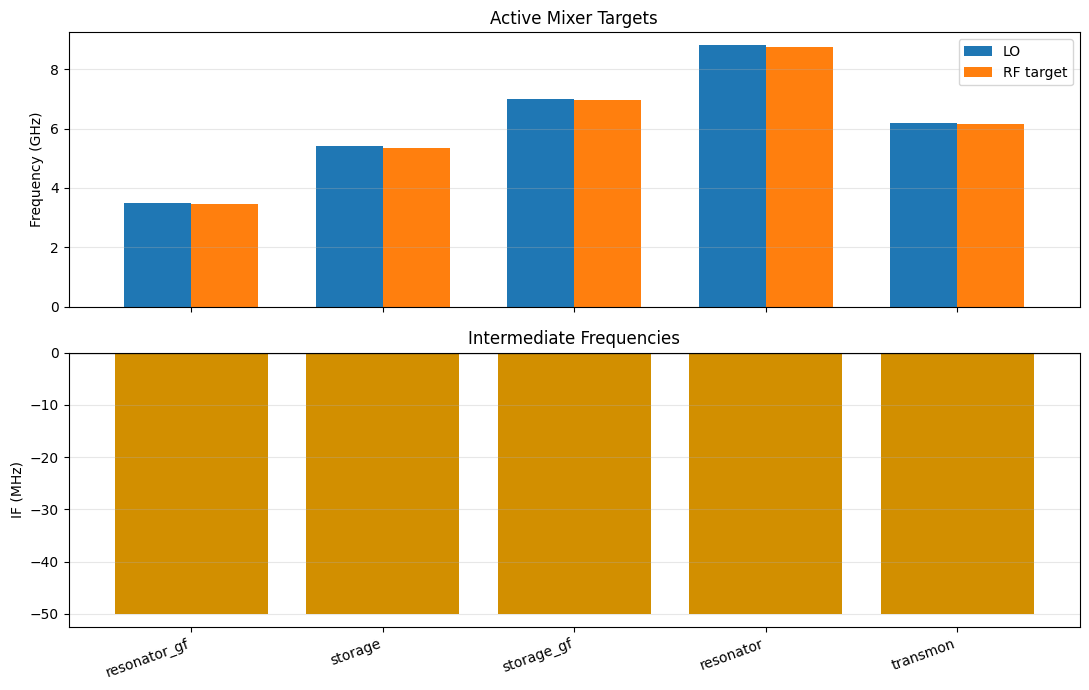

Mixer target summary:
  resonator_gf     LO=3.500000 GHz | IF=-50.000 MHz | RF=3.450000 GHz
  storage          LO=5.400000 GHz | IF=-50.000 MHz | RF=5.350000 GHz
  storage_gf       LO=7.000000 GHz | IF=-50.000 MHz | RF=6.950000 GHz
  resonator        LO=8.800000 GHz | IF=-50.000 MHz | RF=8.750000 GHz
  transmon         LO=6.200000 GHz | IF=-50.000 MHz | RF=6.150000 GHz


In [3]:
import matplotlib.pyplot as plt
import numpy as np

plot_rows = []
if "manual_target_map" in globals() and "manual_elements" in globals():
    plot_targets = manual_target_map
    plot_elements = list(manual_elements)
else:
    active_rows = mixer_targets.get("active", []) if isinstance(mixer_targets, dict) else []
    plot_targets = {row["element"]: row for row in active_rows}
    plot_elements = [row["element"] for row in active_rows]

for element in plot_elements:
    target = plot_targets.get(element, {})
    lo_hz = float(target.get("lo_hz", target.get("lo", np.nan)))
    if_hz = float(target.get("if_hz", target.get("if", np.nan)))
    rf_hz = float(target.get("rf_hz", target.get("rf", lo_hz + if_hz)))
    plot_rows.append((element, lo_hz, if_hz, rf_hz))

if not plot_rows:
    print("No active mixer targets available. Run the setup cells above first.")
else:
    labels = [row[0] for row in plot_rows]
    lo_ghz = np.array([row[1] for row in plot_rows], dtype=float) / 1e9
    if_mhz = np.array([row[2] for row in plot_rows], dtype=float) / 1e6
    rf_ghz = np.array([row[3] for row in plot_rows], dtype=float) / 1e9
    x = np.arange(len(labels))

    fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
    width = 0.35

    axes[0].bar(x - width / 2, lo_ghz, width=width, label="LO")
    axes[0].bar(x + width / 2, rf_ghz, width=width, label="RF target")
    axes[0].set_ylabel("Frequency (GHz)")
    axes[0].set_title("Active Mixer Targets")
    axes[0].grid(axis="y", alpha=0.3)
    axes[0].legend()

    axes[1].bar(x, if_mhz, color="#d28f00")
    axes[1].axhline(0.0, color="black", lw=1, alpha=0.5)
    axes[1].set_ylabel("IF (MHz)")
    axes[1].set_title("Intermediate Frequencies")
    axes[1].grid(axis="y", alpha=0.3)
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(labels, rotation=20, ha="right")

    plt.tight_layout()
    plt.show()

    print("Mixer target summary:")
    for element, lo_hz, if_hz, rf_hz in plot_rows:
        print(
            f"  {element:16s} LO={lo_hz / 1e9:.6f} GHz | "
            f"IF={if_hz / 1e6:+.3f} MHz | RF={rf_hz / 1e9:.6f} GHz"
        )

## 2.5 Active Mixer Target Plot

Plot the current LO, RF, and IF plan for every active mixer target before running either the automatic or the manual calibration path.

## 2. Auto Calibration

Configure the built-in Octave auto-calibration pass here. The next code cell runs auto calibration across all active mixer targets in one step when enabled.

In [4]:
MIXER_CALIBRATION_MODE = "auto"  # "auto", "manual", or "skip"
PERSIST_LO_OVERRIDES = False
AUTO_SA_VALIDATE = False
AUTO_SA_RESTART_QM = True
AUTO_SA_DEVICE_NAME = "sa124b"

LO_GAIN_OVERRIDE_DB = None
EXTERNAL_LO_POWER_OVERRIDE_DBM = None
LO_GAIN_OVERRIDE_MAP = {}
EXTERNAL_LO_POWER_OVERRIDE_MAP = {}

print("Mixer calibration settings:")
print(f"  mode: {MIXER_CALIBRATION_MODE}")
print(f"  persist LO overrides: {PERSIST_LO_OVERRIDES}")
print(f"  auto SA validate: {AUTO_SA_VALIDATE}")
print(f"  auto SA restart QM: {AUTO_SA_RESTART_QM}")
print(f"  auto SA device: {AUTO_SA_DEVICE_NAME}")

Mixer calibration settings:
  mode: auto
  persist LO overrides: False
  auto SA validate: False
  auto SA restart QM: True
  auto SA device: sa124b


In [5]:
applied_gain = {}
applied_ext_lo_power = {}

print("\nAuto calibration plan:")
print(f"  mode:                  {MIXER_CALIBRATION_MODE}")
print(f"  persist_lo_overrides:  {PERSIST_LO_OVERRIDES}")
print(f"  auto_sa_validate:      {AUTO_SA_VALIDATE}")
print(f"  auto_sa_restart_qm:    {AUTO_SA_RESTART_QM}")
print(f"  auto_sa_device_name:   {AUTO_SA_DEVICE_NAME}")
print(f"  targets:               {active_elements}")

if MIXER_CALIBRATION_MODE == "auto":
    for el in active_elements:
        gain_db = LO_GAIN_OVERRIDE_MAP.get(el, LO_GAIN_OVERRIDE_DB)
        if gain_db is not None:
            gain_db = float(gain_db)
            hw.set_octave_gain(el, gain_db)
            rf_out = hw._element_octave_rf_out(el) if hasattr(hw, "_element_octave_rf_out") else None
            if rf_out is not None:
                oct_name, rf_port = rf_out
                session.config_engine.patch_hardware(
                    lambda hw_base, hw_extras, oct_name=oct_name, rf_port=rf_port, gain_db=gain_db:
                    hw_base["octaves"][oct_name]["RF_outputs"][int(rf_port)].__setitem__("gain", gain_db)
                )
            applied_gain[el] = gain_db

        pwr_dbm = EXTERNAL_LO_POWER_OVERRIDE_MAP.get(el, EXTERNAL_LO_POWER_OVERRIDE_DBM)
        if pwr_dbm is not None:
            pwr_dbm = float(pwr_dbm)
            hw.set_external_lo_power(el, pwr_dbm)
            applied_ext_lo_power[el] = pwr_dbm

    if applied_ext_lo_power:
        def _patch_external_lo_power(hw_base, hw_extras):
            qubox = hw_extras.setdefault("__qubox", {})
            if not isinstance(qubox, dict):
                qubox = {}
                hw_extras["__qubox"] = qubox
            power_map = qubox.setdefault("external_lo_power_dbm", {})
            for name, value in applied_ext_lo_power.items():
                power_map[str(name)] = float(value)

        session.config_engine.patch_hardware(_patch_external_lo_power)

    if PERSIST_LO_OVERRIDES and (applied_gain or applied_ext_lo_power):
        session.config_engine.save_hardware()

    auto_results = hw.calibrate_element(
        el=None,
        method="auto",
        save_to_db=True,
        auto_sa_validate=AUTO_SA_VALIDATE,
        auto_sa_restart_qm=AUTO_SA_RESTART_QM,
        auto_sa_device_name=AUTO_SA_DEVICE_NAME,
    )

    print("\nAuto calibration complete.")
    if hasattr(auto_results, "__iter__") and not isinstance(auto_results, (str, bytes, dict)):
        for result in auto_results:
            print(f"  {result}")
    else:
        print(f"  {auto_results}")
elif MIXER_CALIBRATION_MODE == "manual":
    print("Auto calibration skipped because MIXER_CALIBRATION_MODE is set to 'manual'.")
else:
    print("Mixer calibration skipped. Set MIXER_CALIBRATION_MODE to 'auto' or 'manual' to calibrate mixers.")


Auto calibration plan:
  mode:                  auto
  persist_lo_overrides:  False
  auto_sa_validate:      False
  auto_sa_restart_qm:    True
  auto_sa_device_name:   sa124b
  targets:               ['resonator_gf', 'storage', 'storage_gf', 'resonator', 'transmon']
[INFO] 2026-03-22 02:02:48,291 qubox.legacy.hardware.controller: Calibrating 'resonator_gf' with LO=3500.000 MHz, IF=-50.000 MHz
2026-03-22 02:02:50,026 - qm - INFO     - Compiling program
[INFO] 2026-03-22 02:02:55,883 qubox.legacy.hardware.controller: Set output for 'resonator_gf' to RFOutputMode.on
[INFO] 2026-03-22 02:02:55,897 qubox.legacy.hardware.controller: Calibrating 'storage' with LO=5400.000 MHz, IF=-50.000 MHz
2026-03-22 02:02:57,306 - qm - INFO     - Compiling program
[INFO] 2026-03-22 02:03:03,236 qubox.legacy.hardware.controller: Set output for 'storage' to RFOutputMode.on
[INFO] 2026-03-22 02:03:03,247 qubox.legacy.hardware.controller: Calibrating 'storage_gf' with LO=7000.000 MHz, IF=-50.000 MHz
2026-03

## 3. Manual Calibration

Configure the SA124B-driven minimizer path here. The next code cell runs the manual calibration loop across every active mixer target when enabled.

In [6]:
MANUAL_SA_DEVICE_NAME = "sa124b"

QUIET_QM_LOGS = True
LIVE_PLOTS = False
LIVE_PLOT_EVERY = 1

DC_COARSE_RANGE = 0.10
DC_COARSE_N = 11
DC_FINE_RANGE = 0.02
DC_FINE_N = 11

IQ_GAIN_RANGE = 0.10
IQ_PHASE_RANGE = 0.20
IQ_COARSE_N = 11
IQ_FINE_GAIN_RANGE = 0.02
IQ_FINE_PHASE_RANGE = 0.04
IQ_FINE_N = 11

MIN_MAXITER = 60
MIN_XTOL = 1e-4

SA_SPAN_HZ = 2e6
SA_RBW = 10e3
SA_VBW = 10e3
SA_LEVEL_DBM = 0.0
SA_AVG = 1
SA_SETTLE_S = 0.0
SA_EXTRA_CONFIG = {}

SIDEBAND = "lsb"
OBJECTIVE_MODE = "weighted_sum"
W_CARRIER = 1.0
W_IMAGE = 1.0
W_TARGET = 1.0

print("Manual mixer calibration settings:")
print(f"  mode: {MIXER_CALIBRATION_MODE}")
print(f"  SA device: {MANUAL_SA_DEVICE_NAME}")
print(f"  sideband: {SIDEBAND}")
print(f"  objective: {OBJECTIVE_MODE}")

Manual mixer calibration settings:
  mode: auto
  SA device: sa124b
  sideband: lsb
  objective: weighted_sum


In [7]:
manual_targets = resolve_active_mixer_targets(session, include_skipped=True)["active"]
manual_elements = [row["element"] for row in manual_targets]
manual_target_map = {row["element"]: row for row in manual_targets}

if not manual_elements:
    raise RuntimeError("No active mixer elements found for manual calibration.")

manual_freqs = {element: payload["rf_hz"] for element, payload in manual_target_map.items()}
manual_lo_map = {element: payload["lo_hz"] for element, payload in manual_target_map.items()}
manual_if_map = {element: payload["if_hz"] for element, payload in manual_target_map.items()}

cfg = MixerCalibrationConfig(
    sa_span_hz=SA_SPAN_HZ,
    sa_rbw=SA_RBW,
    sa_vbw=SA_VBW,
    sa_level=SA_LEVEL_DBM,
    sa_avg=SA_AVG,
    sa_settle=SA_SETTLE_S,
    sa_extra_config=SA_EXTRA_CONFIG,
    dc_coarse_range=DC_COARSE_RANGE,
    dc_coarse_n=DC_COARSE_N,
    dc_fine_range=DC_FINE_RANGE,
    dc_fine_n=DC_FINE_N,
    iq_gain_range=IQ_GAIN_RANGE,
    iq_phase_range=IQ_PHASE_RANGE,
    iq_coarse_n=IQ_COARSE_N,
    iq_fine_range_gain=IQ_FINE_GAIN_RANGE,
    iq_fine_range_phase=IQ_FINE_PHASE_RANGE,
    iq_fine_n=IQ_FINE_N,
    minimizer_maxiter=MIN_MAXITER,
    minimizer_xtol=MIN_XTOL,
    quiet_qm_logs=QUIET_QM_LOGS,
    live_plot=LIVE_PLOTS,
    live_plot_every=LIVE_PLOT_EVERY,
    sideband=SIDEBAND,
    objective_mode=OBJECTIVE_MODE,
    w_carrier=W_CARRIER,
    w_image=W_IMAGE,
    w_target=W_TARGET,
)

print("Manual calibration targets:")
for el in manual_elements:
    print(f"  {el:20s} LO={manual_lo_map[el] / 1e9:.4f} GHz  IF={manual_if_map[el] / 1e6:.2f} MHz")

print("\nManual calibration plan:")
print(f"  mode:          {MIXER_CALIBRATION_MODE}")
print(f"  targets:       {manual_elements}")
print(f"  SA device:     {MANUAL_SA_DEVICE_NAME}")

if MIXER_CALIBRATION_MODE == "manual":
    sa_dev = session.devices.get(MANUAL_SA_DEVICE_NAME)
    if sa_dev is None:
        raise RuntimeError(f"Spectrum analyzer device {MANUAL_SA_DEVICE_NAME!r} is not available.")

    sa_helper = SAMeasurementHelper(sa_dev, cfg)
    manual_results = []

    for element in manual_elements:
        target_lo = float(manual_lo_map[element])
        target_if = float(manual_if_map[element])
        before = sa_helper.measure_tones(target_lo, target_if)
        result = hw.calibrate_element(
            el=element,
            method="manual_minimizer",
            mixer_cal_config=cfg,
            save_to_db=False,
        )
        after = sa_helper.measure_tones(target_lo, target_if)
        payload = {
            "element": element,
            "result": result,
            "before": before,
            "after": after,
        }
        manual_results.append(payload)

        print(f"\nManual calibration complete for {element}.")
        print(result)
        print("Before:", before)
        print("After: ", after)

    print("\nManual calibration summary:")
    for payload in manual_results:
        print(f"  {payload['element']}: done")
elif MIXER_CALIBRATION_MODE == "auto":
    print("Manual calibration skipped because MIXER_CALIBRATION_MODE is set to 'auto'.")
else:
    print("Mixer calibration skipped. Set MIXER_CALIBRATION_MODE to 'auto' or 'manual' to calibrate mixers.")

Manual calibration targets:
  resonator_gf         LO=3.5000 GHz  IF=-50.00 MHz
  storage              LO=5.4000 GHz  IF=-50.00 MHz
  storage_gf           LO=7.0000 GHz  IF=-50.00 MHz
  resonator            LO=8.8000 GHz  IF=-50.00 MHz
  transmon             LO=6.2000 GHz  IF=-50.00 MHz

Manual calibration plan:
  mode:          auto
  targets:       ['resonator_gf', 'storage', 'storage_gf', 'resonator', 'transmon']
  SA device:     sa124b
Manual calibration skipped because MIXER_CALIBRATION_MODE is set to 'auto'.
